# 03 — Modélisation de la potabilité

Objectif : comparer plusieurs classifieurs avec séparation stratifiée, prétraitement intégré et métriques complètes.

## 1. Configuration

In [1]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
DATA_RAW=PROJECT_ROOT/"data"/"raw"; DATA_PROCESSED=PROJECT_ROOT/"data"/"processed"
FIGURES=PROJECT_ROOT/"reports"/"figures"; RESULTS=PROJECT_ROOT/"reports"/"results"; MODELS=PROJECT_ROOT/"models"
for p in [DATA_PROCESSED,FIGURES,RESULTS,MODELS]: p.mkdir(parents=True,exist_ok=True)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
RANDOM_STATE=42
pd.set_option("display.max_columns",100)

In [2]:
from src.data_cleaning import load_potability,basic_cleaning
from sklearn.model_selection import train_test_split
from src.preprocessing import make_model_pipeline
from src.modeling import classification_models
from src.evaluation import classification_metrics,cross_validation_table,save_confusion_matrix,save_roc_curve
from src.interpretability import permutation_importance_table
import joblib

## 2. X et y

In [3]:
df=basic_cleaning(load_potability(DATA_RAW/"water_potability.csv"),target="Potability")
X=df.drop(columns="Potability"); y=df["Potability"].astype(int)
display(y.value_counts(normalize=True))

Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64

## 3. Train/test

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,stratify=y,random_state=RANDOM_STATE)
print(X_train.shape,X_test.shape)

(2620, 9) (656, 9)


## 4. Modèles et pipelines

Médiane dans le pipeline ; standardisation pour Logistic Regression et SVM.

In [5]:
models=classification_models(RANDOM_STATE); models

OrderedDict([('Logistic Regression',
              LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)),
             ('Random Forest',
              RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                                     random_state=42)),
             ('SVM-RBF',
              SVC(class_weight='balanced', probability=True, random_state=42)),
             ('XGBoost',
              XGBClassifier(base_score=None, booster=None, callbacks=None,
                            colsample_bylevel=None, colsample_bynode=None,
                            colsample_bytree=0.9, device=None, early_stopping_rounds=None,
                            enable_categorical=False, eval_metric='logloss',
                            feature_types=None, feature_weights=None, gamma=None,
                            grow_policy=None, importance_type=None,
                            interaction_constraints=None, learning_rate=0.05, max_bin=None,
   

## 5. Validation croisée

In [6]:
cv_rows=[]; pipes={}
for name,model in models.items():
    pipe=make_model_pipeline(model,X.columns,scale=name in ["Logistic Regression","SVM-RBF"]); pipes[name]=pipe
    cv=cross_validation_table(pipe,X_train,y_train,5,RANDOM_STATE)
    for _,r in cv.iterrows(): cv_rows.append({"model":name,**r.to_dict()})
cv_results=pd.DataFrame(cv_rows); display(cv_results.pivot(index="model",columns="metric",values="mean").round(4))

metric,accuracy,f1,precision,recall,roc_auc
model,,,,,
Logistic Regression,0.4947,0.4155,0.3783,0.4619,0.4768
Random Forest,0.6740,0.4215,0.6844,0.3063,0.6927
SVM-RBF,0.6668,0.5704,0.5733,0.5694,0.7036
XGBoost,0.6592,0.4745,0.5936,0.3973,0.6763


## 6. Test final

In [7]:
rows=[]; fitted={}
for name,pipe in pipes.items():
    pipe.fit(X_train,y_train); fitted[name]=pipe; rows.append({"model":name,**classification_metrics(pipe,X_test,y_test)})
test_results=pd.DataFrame(rows).sort_values(["f1","roc_auc"],ascending=False).reset_index(drop=True); display(test_results.round(4))

,model,accuracy,precision,recall,f1,roc_auc
0,SVM-RBF,0.6220,0.5159,0.5078,0.5118,0.6440
1,Logistic Regression,0.5244,0.4146,0.5312,0.4658,0.5474
2,XGBoost,0.6494,0.5844,0.3516,0.4390,0.6518
3,Random Forest,0.6723,0.6952,0.2852,0.4044,0.6586


## 7. Meilleur modèle

In [8]:
best_name=test_results.iloc[0]["model"]; best=fitted[best_name]; print(best_name)

SVM-RBF


## 8. Matrice de confusion et ROC

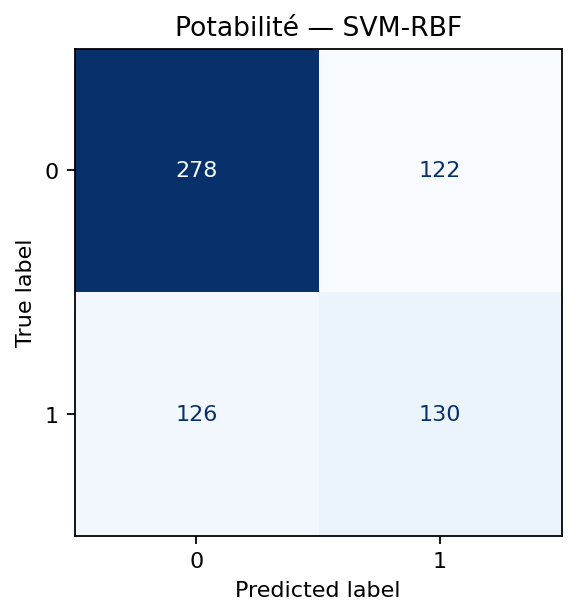

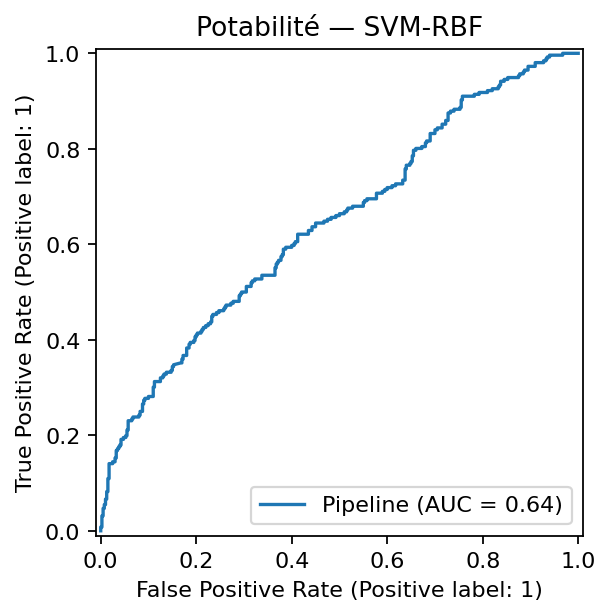

In [9]:
cm=FIGURES/"potability_confusion_matrix.png"; roc=FIGURES/"potability_roc_curve.png"
save_confusion_matrix(best,X_test,y_test,f"Potabilité — {best_name}",cm); save_roc_curve(best,X_test,y_test,f"Potabilité — {best_name}",roc)
from IPython.display import Image,display
display(Image(filename=str(cm))); display(Image(filename=str(roc)))

## 9. Interprétabilité

,feature,importance_mean,importance_std
0,Sulfate,0.072071,0.015633
1,ph,0.064888,0.012942
2,Solids,0.050331,0.017162
3,Chloramines,0.027766,0.009042
4,Hardness,0.019867,0.009268
5,Conductivity,-0.000419,0.015322
6,Organic_carbon,-0.001989,0.012724
7,Turbidity,-0.006300,0.009129
8,Trihalomethanes,-0.015485,0.015168


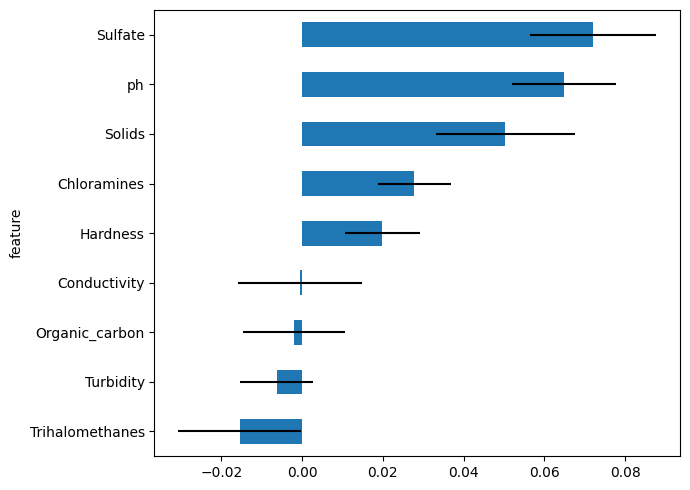

In [10]:
imp=permutation_importance_table(best,X_test,y_test); display(imp)
imp.sort_values("importance_mean").plot.barh(x="feature",y="importance_mean",xerr="importance_std",figsize=(7,5),legend=False); plt.tight_layout(); plt.show()

## 10. Sauvegarde

In [11]:
cv_results.to_csv(RESULTS/"potability_cv_metrics.csv",index=False); test_results.to_csv(RESULTS/"potability_test_metrics.csv",index=False); imp.to_csv(RESULTS/"potability_feature_importance.csv",index=False); joblib.dump(best,MODELS/"potability_best_model.pkl")

['C:\\Users\\UltraPc\\Documents\\pfe\\sujet 4\\models\\potability_best_model.pkl']

## 11. Discussion

Commenter F1, ROC-AUC, précision/rappel, stabilité en validation croisée, erreurs et variables importantes.